##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class**

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold
  - The model only detects objects from the **COCO dataset (80 classes)**  


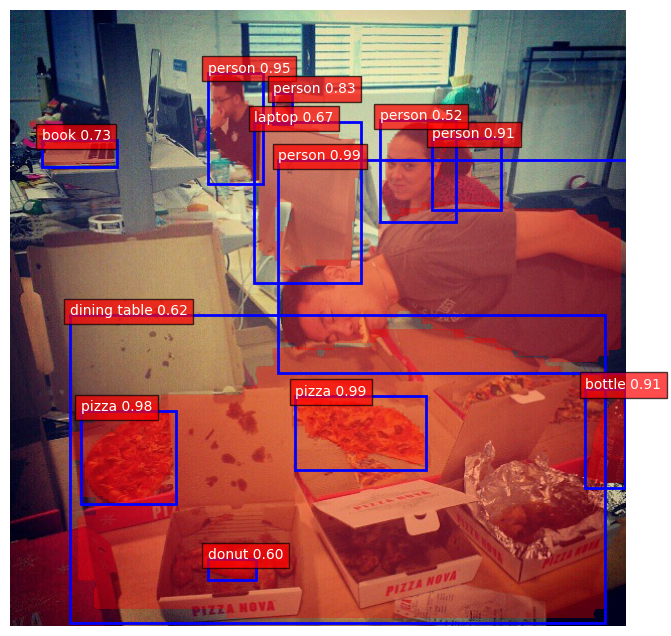

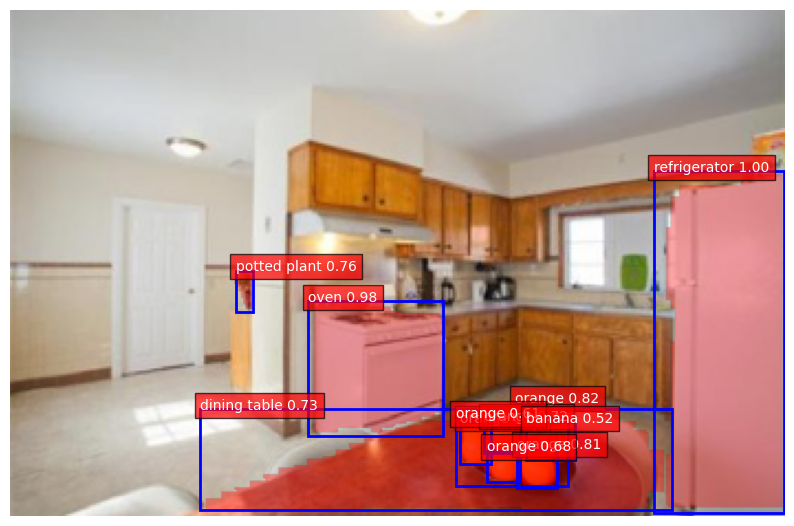

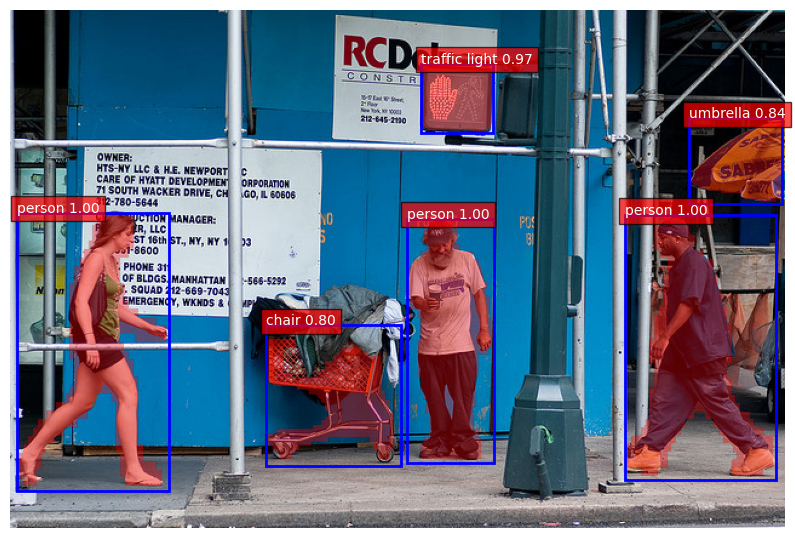

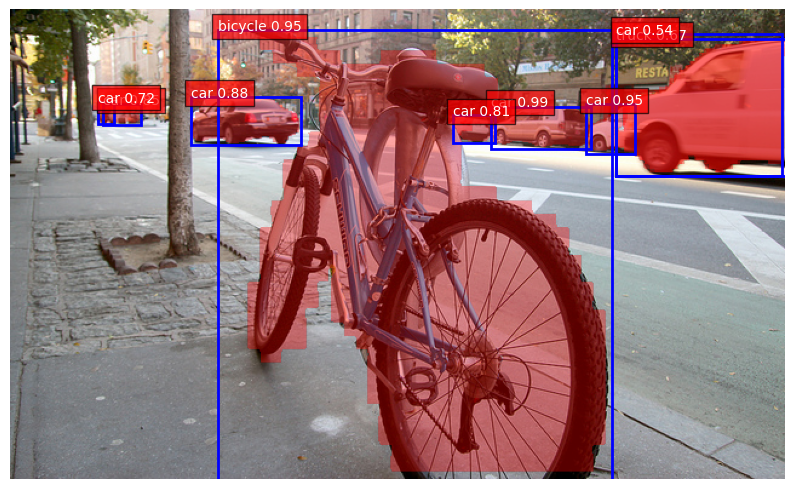

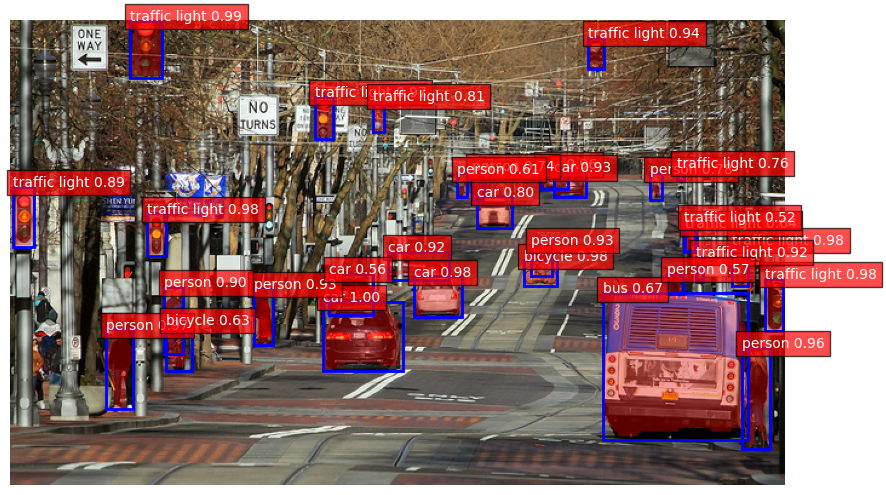

In [2]:
import tensorflow_hub as hub
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO


detector = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")

# 5 image links as requested
urls = [
    "http://images.cocodataset.org/val2017/000000292446.jpg",
    "http://images.cocodataset.org/val2017/000000037777.jpg",
    "http://images.cocodataset.org/val2017/000000252219.jpg",
    "http://images.cocodataset.org/val2017/000000174482.jpg",
    "http://images.cocodataset.org/val2017/000000309391.jpg"
]

labels = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep',
    21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe',
    27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase',
    34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite',
    39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard',
    43: 'tennis racket', 44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork',
    49: 'knife', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple',
    54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog',
    59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch',
    64: 'potted plant', 65: 'bed', 67: 'dining table', 70: 'toilet', 72: 'tv',
    73: 'laptop', 74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone',
    78: 'microwave', 79: 'oven', 80: 'toaster', 81: 'sink', 82: 'refrigerator',
    84: 'book', 85: 'clock', 86: 'vase', 87: 'scissors', 88: 'teddy bear',
    89: 'hair drier', 90: 'toothbrush'
}

def show_prediction(image, output, threshold=0.5):
    boxes = output["detection_boxes"][0].numpy()
    classes = output["detection_classes"][0].numpy().astype(int)
    scores = output["detection_scores"][0].numpy()
    masks = output["detection_masks"][0].numpy()

    h, w, _ = image.shape

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    ax = plt.gca()

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)


        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)


        name = labels.get(classes[i], str(classes[i]))
        plt.text(x1, y1, f"{name} {scores[i]:.2f}",
                 color="white", fontsize=10,
                 bbox=dict(facecolor="red", alpha=0.7))


        # creating mask
        mask = masks[i] > 0.5
        mask = Image.fromarray(mask.astype(np.uint8) * 255).resize((x2 - x1, y2 - y1))
        mask = np.array(mask) > 0

        overlay = np.zeros((h, w, 4))
        overlay[y1:y2, x1:x2, 0] = mask
        overlay[y1:y2, x1:x2, 3] = mask * 0.35
        ax.imshow(overlay)

    plt.axis("off")
    plt.show()

# Predict and visualize 5 images
for url in urls:
    image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    image = np.array(image)
    image_tensor = image[np.newaxis, ...]

    output = detector(image_tensor)

    show_prediction(image, output, threshold=0.5)

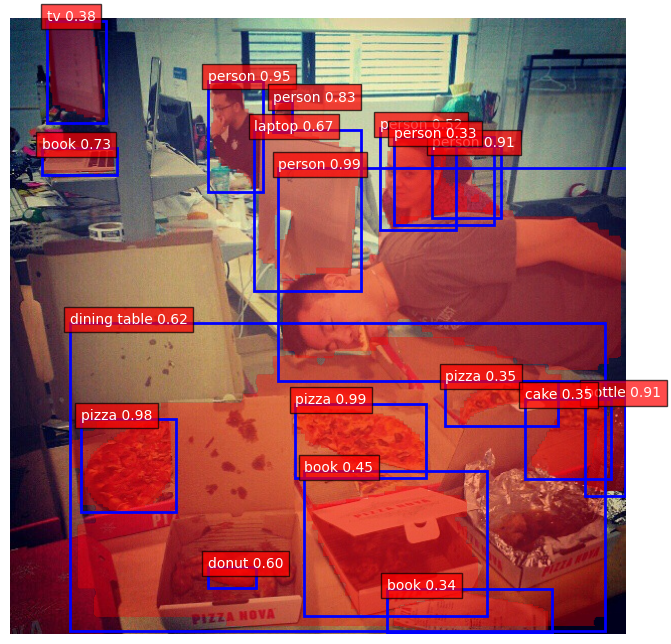

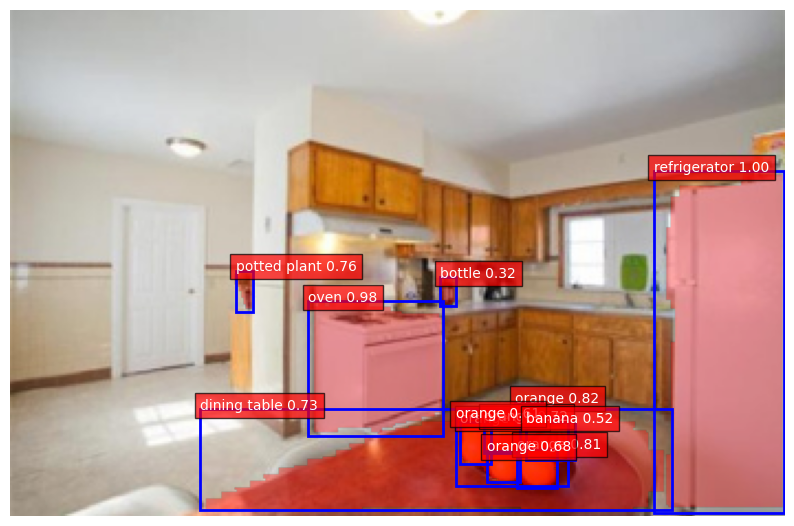

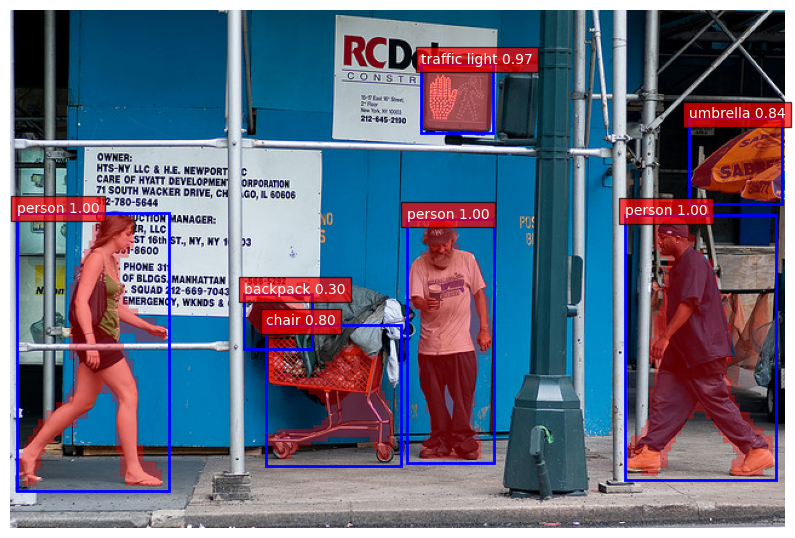

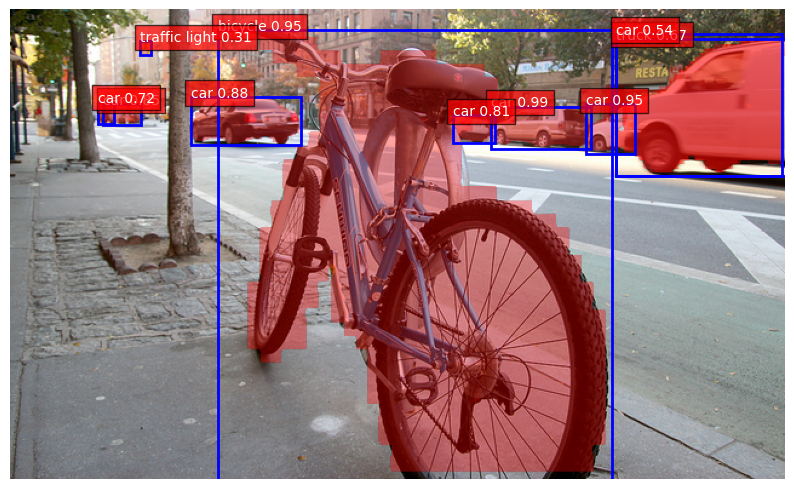

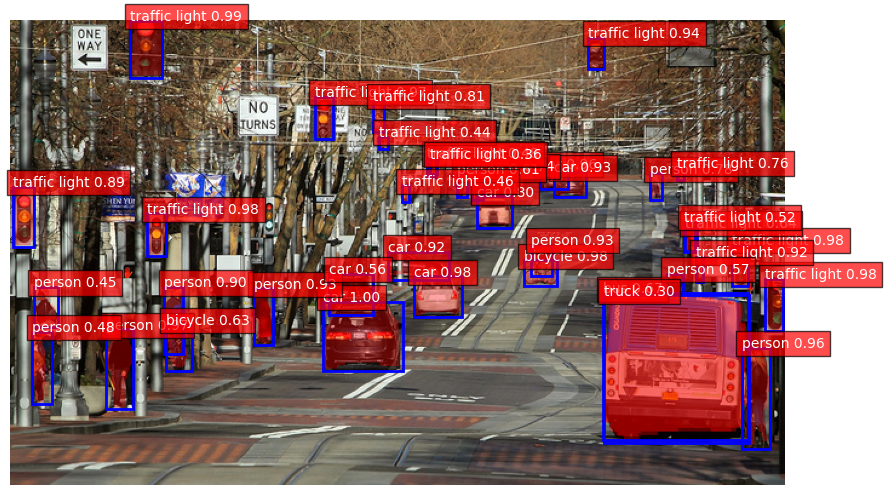

In [3]:
# 2nd threshold == 0.3
for url in urls:
    image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    image = np.array(image)
    image_tensor = image[np.newaxis, ...]

    output = detector(image_tensor)

    show_prediction(image, output, threshold=0.3)